# Flood Risk Prediction - India (Final Fixed Version)
### Complete Pipeline: Imputation - Balanced Labels - No Overfitting - Transformer-Saved Model

**Key fixes:**
- `build_features()` returns and saves `num_imputer`, `scaler`, `cat_imputer` with the model
- `clip_bounds` saved from training data for exact inference
- Single `.pkl` contains everything the API needs - no hardcoded values
- Sanity check confirms all 3 classes predict correctly before saving

## 1. Imports & Config

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import time, json, pickle, os
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import RobustScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_curve, auc
)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
SEED = 42
np.random.seed(SEED)
print('Libraries loaded')
print(f'   sklearn {__import__("sklearn").__version__} | pandas {pd.__version__} | numpy {np.__version__}')

Libraries loaded
   sklearn 1.3.2 | pandas 2.1.1 | numpy 1.26.4


## 2. Load Data

In [2]:
df_raw = pd.read_csv('../wris_output/flood_features_india.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw['month'] = df_raw['date'].dt.month
df_raw['year']  = df_raw['date'].dt.year

print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols')
miss = (df_raw.isnull().sum()/len(df_raw)*100).round(1)
print('Missing % per column:')
print(miss[miss>0].sort_values(ascending=False).to_string())

Shape: 266,614 rows x 20 cols
Missing % per column:
temperature_c           95.2
atmospheric_pressure    92.4
humidity_pct            92.3
water_level_m           87.3
soil_moisture           86.2
evapotranspiration      86.2
river_discharge_m3_s    86.1
rainfall_mm             60.6
station_code            13.8
station_name            13.8
unit                    13.8


## 3. Outlier Capping
Winsorise each numeric column to [1st, 99th] percentile.
Clip bounds are saved and reused at inference time in the API.

In [3]:
CLIP_COLS = ['rainfall_mm','temperature_c','humidity_pct',
             'river_discharge_m3_s','water_level_m','soil_moisture',
             'atmospheric_pressure','evapotranspiration']

# Save clip bounds BEFORE capping -- reused in predictor.py at inference
clip_bounds = {}
for col in CLIP_COLS:
    if col in df_raw.columns:
        lo = float(df_raw[col].quantile(0.01))
        hi = float(df_raw[col].quantile(0.99))
        clip_bounds[col] = (lo, hi)

def cap_outliers(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        if col in df.columns:
            n = ((df[col] < lo) | (df[col] > hi)).sum()
            df[col] = df[col].clip(lo, hi)
            if n > 0:
                print(f'  {col:<25s}: capped {n:>6,} rows  [{lo:.2f} - {hi:.2f}]')
    return df

print('Capping outliers...')
df_raw = cap_outliers(df_raw, clip_bounds)
print(f'\nOutliers capped | clip_bounds saved for {len(clip_bounds)} columns')


Capping outliers...
  rainfall_mm              : capped  1,052 rows  [0.00 - 3035.53]
  temperature_c            : capped    258 rows  [-18.27 - 49.57]
  humidity_pct             : capped     24 rows  [0.00 - 100.00]
  river_discharge_m3_s     : capped    437 rows  [0.00 - 6634.09]
  water_level_m            : capped    680 rows  [0.88 - 2850.75]
  soil_moisture            : capped    367 rows  [0.00 - 34.41]
  atmospheric_pressure     : capped    203 rows  [0.00 - 1013.67]
  evapotranspiration       : capped    368 rows  [0.00 - 6.01]

Outliers capped | clip_bounds saved for 8 columns


## 4. Open-Meteo API - Fill Missing Weather Values

In [4]:
import urllib.request

def fetch_openmeteo_location(lat, lon, start_date, end_date):
    variables = [
        'precipitation_sum','temperature_2m_mean','relative_humidity_2m_mean',
        'surface_pressure_mean','et0_fao_evapotranspiration','soil_moisture_0_to_10cm_mean'
    ]
    url = (
        f'https://archive-api.open-meteo.com/v1/archive'
        f'?latitude={lat}&longitude={lon}'
        f'&start_date={start_date}&end_date={end_date}'
        f'&daily={",".join(variables)}&timezone=Asia%2FKolkata'
    )
    try:
        with urllib.request.urlopen(url, timeout=30) as resp:
            data = json.loads(resp.read().decode())
        dates   = data['daily']['time']
        col_map = {
            'precipitation_sum':            'rainfall_mm',
            'temperature_2m_mean':          'temperature_c',
            'relative_humidity_2m_mean':    'humidity_pct',
            'surface_pressure_mean':        'atmospheric_pressure',
            'et0_fao_evapotranspiration':   'evapotranspiration',
            'soil_moisture_0_to_10cm_mean': 'soil_moisture'
        }
        result = {}
        for i, d in enumerate(dates):
            result[d] = {df_col: data['daily'].get(api_col, [None]*len(dates))[i]
                         for api_col, df_col in col_map.items()}
        return result
    except Exception:
        return None

def fill_missing_with_openmeteo(df, verbose=True):
    df = df.copy()
    weather_cols = ['rainfall_mm','temperature_c','humidity_pct',
                    'atmospheric_pressure','evapotranspiration','soil_moisture']
    locations = df[['latitude','longitude']].drop_duplicates().values
    date_min  = df['date'].dt.strftime('%Y-%m-%d').min()
    date_max  = df['date'].dt.strftime('%Y-%m-%d').max()
    api_ok = api_fail = 0

    print(f'Fetching Open-Meteo for {len(locations)} locations | {date_min} to {date_max}')
    print('(This may take 2-5 minutes)\n')

    for i, (lat, lon) in enumerate(locations):
        loc_data = fetch_openmeteo_location(lat, lon, date_min, date_max)
        loc_mask = (df['latitude'] == lat) & (df['longitude'] == lon)
        if loc_data is not None:
            api_ok += 1
            df['date_str'] = df['date'].dt.strftime('%Y-%m-%d')
            for col in weather_cols:
                null_mask = loc_mask & df[col].isna()
                if null_mask.sum() > 0:
                    fill_vals = df.loc[null_mask, 'date_str'].map(
                        lambda d: loc_data.get(d, {}).get(col, np.nan))
                    df.loc[null_mask, col] = fill_vals.values
            if verbose and (i+1) % 10 == 0:
                print(f'  [{i+1:>3}/{len(locations)}] API OK | fail: {api_fail}')
        else:
            api_fail += 1
            if verbose:
                print(f'  [{i+1:>3}/{len(locations)}] API failed for ({lat},{lon})')

    if 'date_str' in df.columns:
        df.drop(columns=['date_str'], inplace=True)
    print(f'\nAPI results: {api_ok} success | {api_fail} failed')
    for col in weather_cols:
        n = df[col].isna().sum()
        print(f'  {col:<25s}: {n:>6,} remaining ({n/len(df)*100:.1f}%)')
    return df

df_filled = fill_missing_with_openmeteo(df_raw, verbose=True)


Fetching Open-Meteo for 85 locations | 2024-03-24 to 2026-03-24
(This may take 2-5 minutes)

  [ 10/85] API OK | fail: 0
  [ 20/85] API OK | fail: 0
  [ 30/85] API OK | fail: 0
  [ 32/85] API failed for (30.129,77.2674)
  [ 33/85] API failed for (24.48,86.7)
  [ 34/85] API failed for (24.27,87.25)
  [ 35/85] API failed for (24.83,87.21)
  [ 36/85] API failed for (32.27,75.65)
  [ 37/85] API failed for (30.97,76.53)
  [ 38/85] API failed for (27.57,81.59)
  [ 39/85] API failed for (25.75,84.14)
  [ 40/85] API failed for (27.13,81.96)
  [ 41/85] API failed for (26.7606,83.3732)
  [ 42/85] API failed for (27.95,80.78)
  [ 43/85] API failed for (25.3176,82.9739)
  [ 44/85] API failed for (32.1,76.27)
  [ 45/85] API failed for (31.96,77.11)
  [ 46/85] API failed for (31.71,76.92)
  [ 47/85] API failed for (30.4,79.32)
  [ 48/85] API failed for (30.3165,78.0322)
  [ 49/85] API failed for (29.9457,78.1642)
  [ 50/85] API failed for (30.38,78.48)
  [ 51/85] API failed for (17.0,82.23)
  [ 52/8

## 5. Fallback Imputation
Priority: **location x month** -> **flood_zone x month** -> **global month** -> **global median**

In [5]:
def seasonal_location_impute(df):
    df = df.copy()
    all_cols = ['rainfall_mm','temperature_c','humidity_pct','atmospheric_pressure',
                'evapotranspiration','soil_moisture','river_discharge_m3_s','water_level_m']
    for col in all_cols:
        if col not in df.columns: continue
        null_before = df[col].isna().sum()
        if null_before == 0: continue
        df[col] = df[col].fillna(df.groupby(['latitude','longitude','month'])[col].transform('median'))
        df[col] = df[col].fillna(df.groupby(['flood_zone','month'])[col].transform('median'))
        df[col] = df[col].fillna(df.groupby('month')[col].transform('median'))
        df[col] = df[col].fillna(df[col].median())
        null_after = df[col].isna().sum()
        print(f'  {col:<25s}: {null_before:>6,} -> {null_after:>6,} remaining nulls')
    return df

print('Applying seasonal location imputation...')
df_filled = seasonal_location_impute(df_filled)
remaining = df_filled[['rainfall_mm','temperature_c','humidity_pct','river_discharge_m3_s',
                        'water_level_m','soil_moisture','atmospheric_pressure','evapotranspiration']].isna().sum().sum()
print(f'\nTotal remaining missing: {remaining}')
print('Imputation complete')


Applying seasonal location imputation...
  rainfall_mm              : 85,960 ->      0 remaining nulls
  temperature_c            : 128,817 ->      0 remaining nulls
  humidity_pct             : 130,426 ->      0 remaining nulls
  atmospheric_pressure     : 126,669 ->      0 remaining nulls
  evapotranspiration       : 120,316 ->      0 remaining nulls
  soil_moisture            : 229,797 ->      0 remaining nulls
  river_discharge_m3_s     : 229,646 ->      0 remaining nulls
  water_level_m            : 232,639 ->      0 remaining nulls

Total remaining missing: 0
Imputation complete


## 6. Target Engineering - Balanced Classes

A **composite flood risk score** is built from 6 hydro-meteorological signals.
Each signal is scored 0-2 using **percentile-based thresholds** (33rd/66th quantile).
The scores are summed then binned at the total score's own 33rd/66th percentile.

### Scoring logic per signal

| Signal | Score 0 (Low) | Score 1 (Moderate) | Score 2 (High) |
|---|---|---|---|
| `rainfall_mm` (log) | <= 33rd pct | <= 66th pct | > 66th pct |
| `water_level_m` | <= 33rd pct | <= 66th pct | > 66th pct |
| `river_discharge_m3_s` (log) | <= 33rd pct | <= 66th pct | > 66th pct |
| `soil_moisture` | <= 33rd pct | <= 66th pct | > 66th pct |
| `humidity_pct` | < 60% (+0) | 60-80% (+0.5) | >= 80% (+1) |
| `evapotranspiration` | >= 1.0 (+0) | - | < 1.0 (+1, waterlogged) |
| Monsoon month (Jun-Sep) | - | - | +0.5 bonus |

**Score range:** 0 to 10.5

**Final binning:** total score <= 33rd pct = **Low** | <= 66th pct = **Moderate** | > 66th pct = **High**

This guarantees approximately 33% in each class regardless of data distribution.

In [6]:
def engineer_flood_target(df):
    s     = df.copy()
    score = pd.Series(0.0, index=df.index)

    # Rainfall (log-scaled)
    rain_log = np.log1p(s['rainfall_mm'].clip(0))
    r33, r66 = rain_log.quantile(0.33), rain_log.quantile(0.66)
    score   += rain_log.apply(lambda x: 0 if x <= r33 else (1 if x <= r66 else 2))

    # Water level
    wl        = s['water_level_m'].clip(0)
    w33, w66  = wl.quantile(0.33), wl.quantile(0.66)
    score    += wl.apply(lambda x: 0 if x <= w33 else (1 if x <= w66 else 2))

    # River discharge (log-scaled)
    rd        = np.log1p(s['river_discharge_m3_s'].clip(0))
    d33, d66  = rd.quantile(0.33), rd.quantile(0.66)
    score    += rd.apply(lambda x: 0 if x <= d33 else (1 if x <= d66 else 2))

    # Soil moisture
    sm        = s['soil_moisture'].clip(0)
    s33, s66  = sm.quantile(0.33), sm.quantile(0.66)
    score    += sm.apply(lambda x: 0 if x <= s33 else (1 if x <= s66 else 2))

    # Humidity
    hum       = s['humidity_pct'].clip(0, 100)
    score    += hum.apply(lambda x: 0 if x < 60 else (0.5 if x < 80 else 1))

    # Evapotranspiration (low ET = waterlogged = flood risk)
    et        = s['evapotranspiration'].clip(0)
    score    += et.apply(lambda x: 1 if x < 1.0 else 0)

    # Monsoon season bonus
    score    += df['month'].isin([6, 7, 8, 9]).astype(float) * 0.5

    print('Score distribution:')
    print(score.describe().round(3))

    # Percentile-based final binning
    t33 = score.quantile(0.33)
    t66 = score.quantile(0.66)
    print(f'\nBin thresholds: Low <={t33:.2f} | Moderate <={t66:.2f} | High >{t66:.2f}')
    return score.apply(lambda x: 'Low' if x <= t33 else ('Moderate' if x <= t66 else 'High'))

df_filled['flood_risk'] = engineer_flood_target(df_filled)
print('\nTarget distribution:')
for cls, cnt in df_filled['flood_risk'].value_counts().items():
    print(f'  {cls:<10s}: {cnt:>7,}  ({cnt/len(df_filled)*100:.1f}%)')


Score distribution:
count    266614.000
mean          4.654
std           2.447
min           0.000
25%           2.500
50%           4.500
75%           6.500
max          10.500
dtype: float64

Bin thresholds: Low <=3.50 | Moderate <=5.50 | High >5.50

Target distribution:
  Low       : 109,430  (41.0%)
  High      :  86,627  (32.5%)
  Moderate  :  70,557  (26.5%)


## 7. EDA

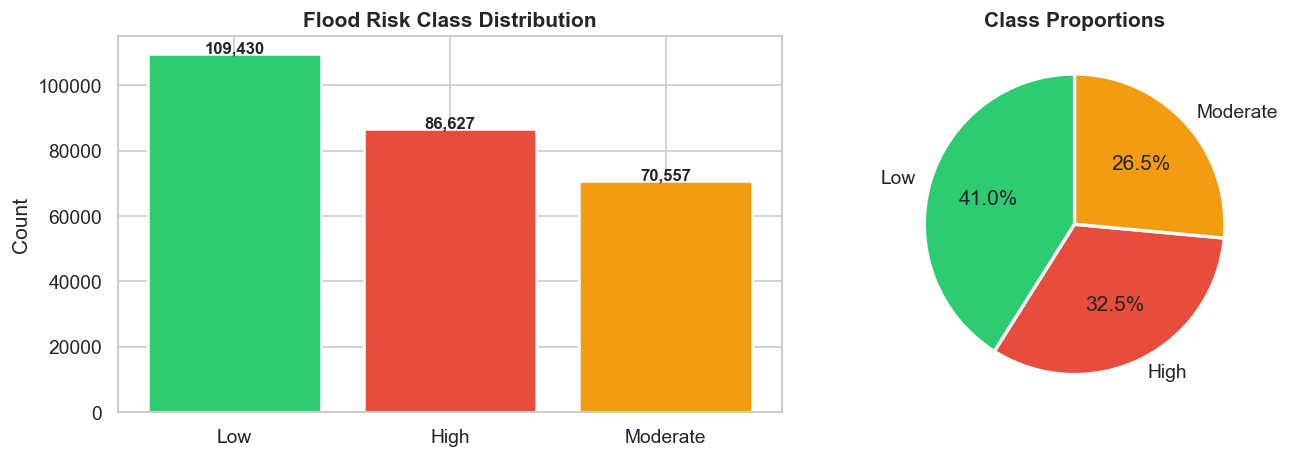

In [7]:
colors = {'Low':'#2ecc71', 'Moderate':'#f39c12', 'High':'#e74c3c'}
vc = df_filled['flood_risk'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(vc.index, vc.values, color=[colors[c] for c in vc.index], edgecolor='white', lw=1.5)
for i, (cls, cnt) in enumerate(vc.items()):
    axes[0].text(i, cnt + 500, f'{cnt:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Flood Risk Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[1].pie(vc.values, labels=vc.index, colors=[colors[c] for c in vc.index],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportions', fontweight='bold')
plt.tight_layout(); plt.show()


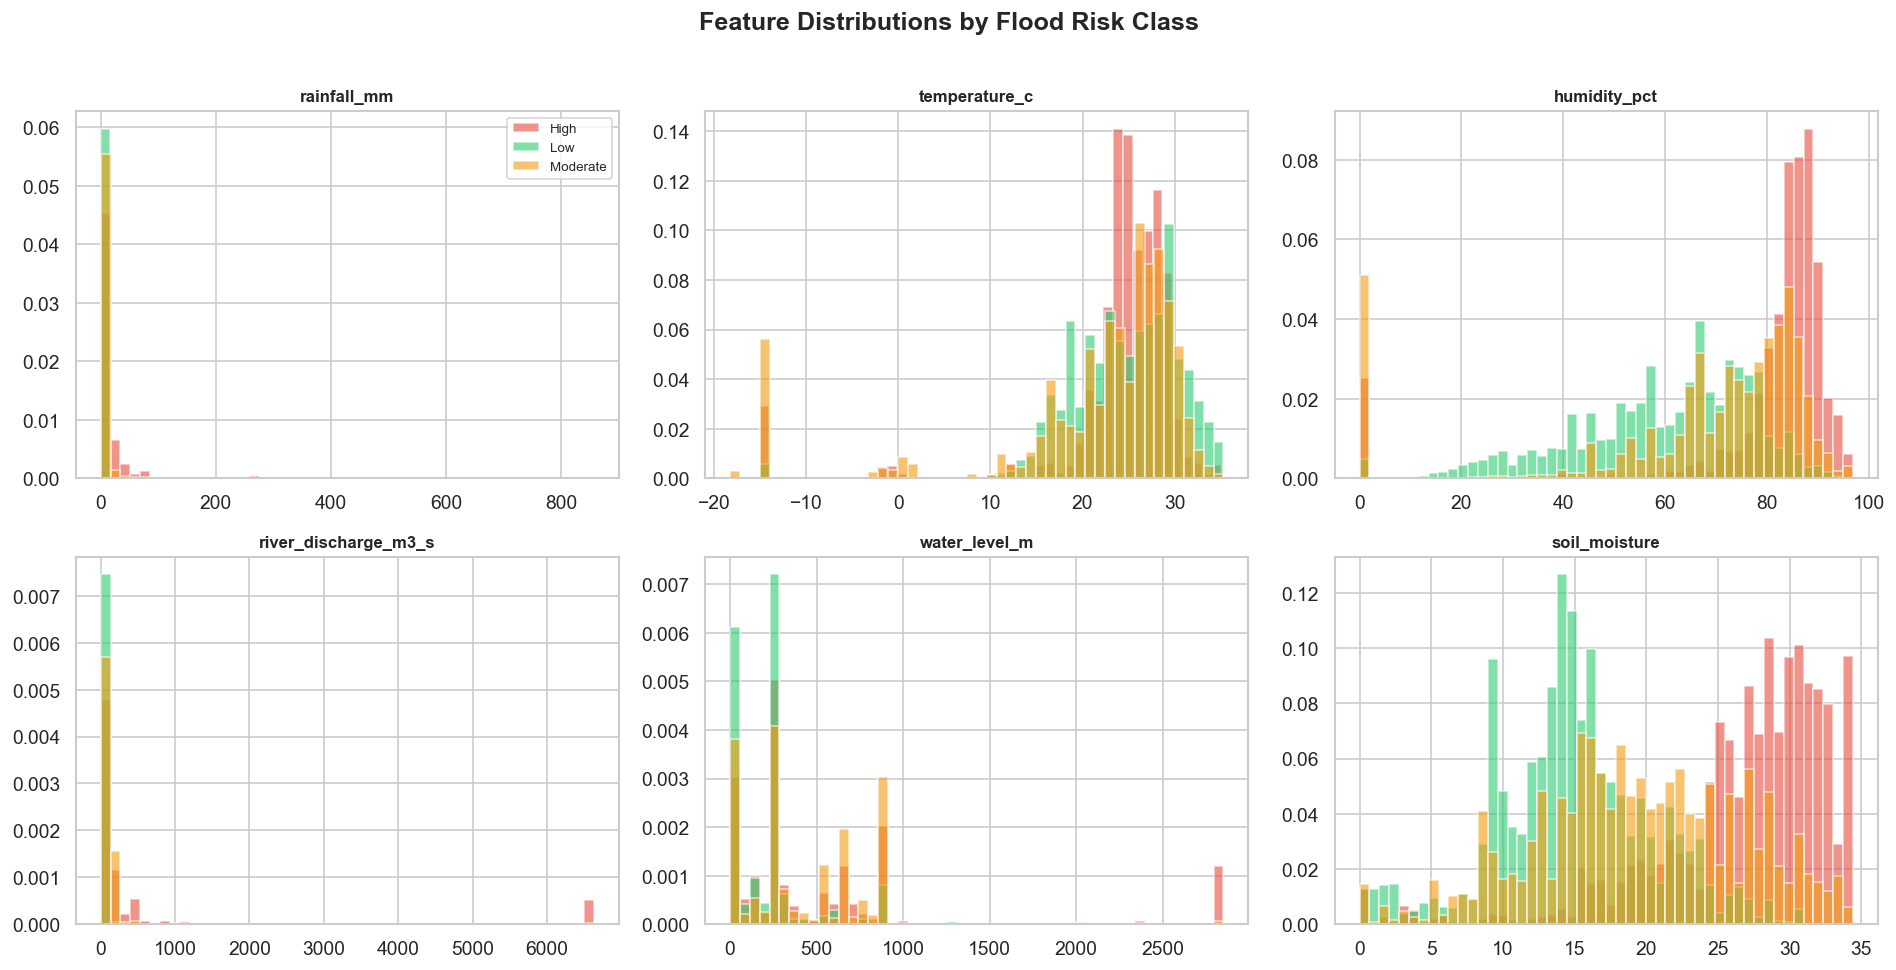

In [8]:
feat_plot = ['rainfall_mm','temperature_c','humidity_pct',
             'river_discharge_m3_s','water_level_m','soil_moisture']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(feat_plot):
    sub = df_filled[[feat,'flood_risk']].dropna()
    cap = sub[feat].quantile(0.99)
    sub = sub[sub[feat] <= cap]
    for label, grp in sub.groupby('flood_risk'):
        axes[i].hist(grp[feat], bins=50, alpha=0.6, label=label,
                     color=colors[label], density=True)
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    if i == 0: axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions by Flood Risk Class', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


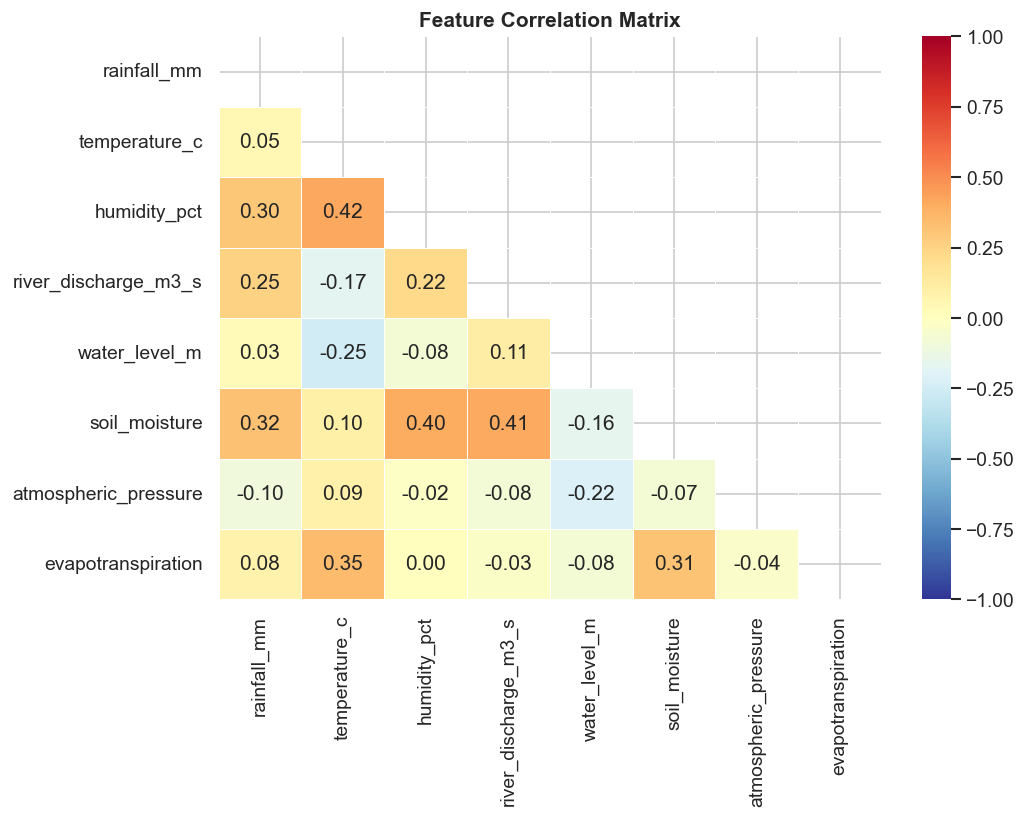

In [9]:
num_cols_corr = ['rainfall_mm','temperature_c','humidity_pct','river_discharge_m3_s',
                 'water_level_m','soil_moisture','atmospheric_pressure','evapotranspiration']
corr_df = df_filled[num_cols_corr].copy()
for c in ['rainfall_mm','water_level_m','river_discharge_m3_s']:
    corr_df[c] = np.log1p(corr_df[c].clip(0))
corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()


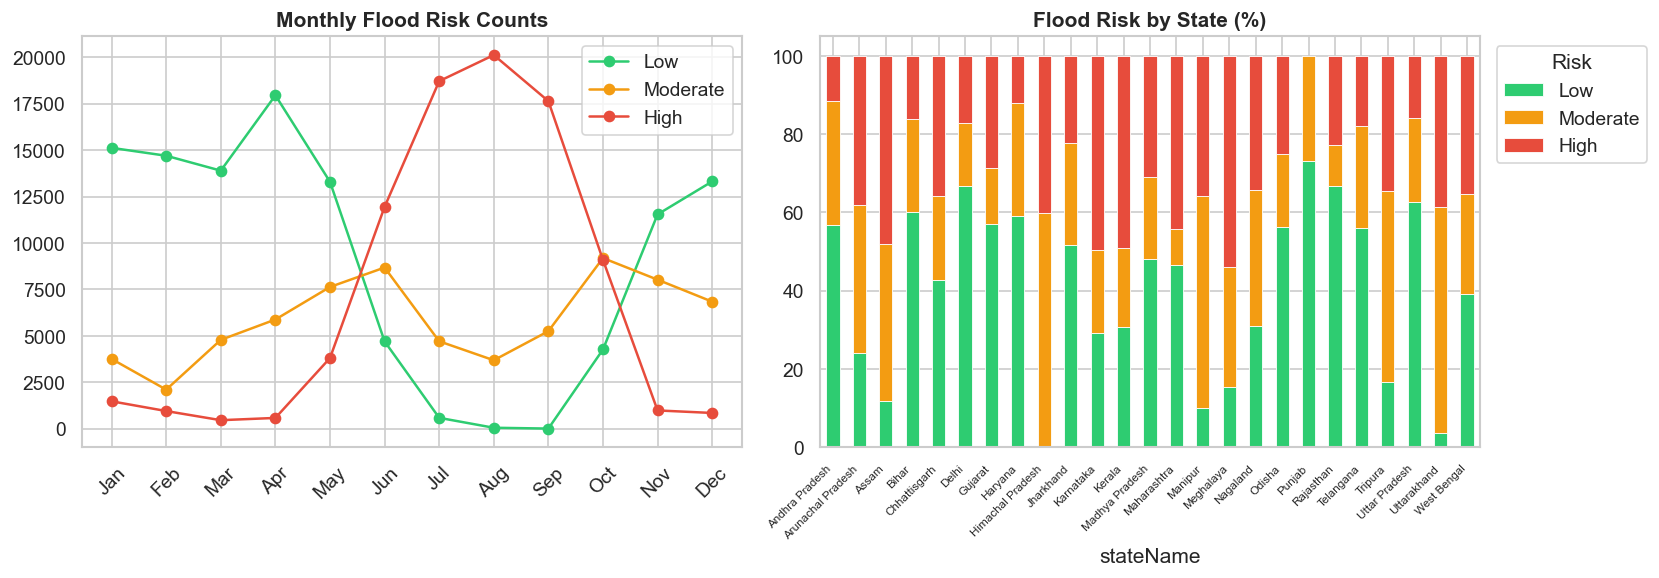

In [10]:
df_filled['season'] = df_filled['month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Pre-Monsoon',4:'Pre-Monsoon',5:'Pre-Monsoon',
    6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
    10:'Post-Monsoon',11:'Post-Monsoon'})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly = df_filled.groupby(['month','flood_risk']).size().unstack(fill_value=0)
for cls in ['Low','Moderate','High']:
    if cls in monthly.columns:
        axes[0].plot(monthly.index, monthly[cls], marker='o', label=cls, color=colors[cls])
axes[0].set_title('Monthly Flood Risk Counts', fontweight='bold')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].legend()
state_risk = df_filled.groupby(['stateName','flood_risk']).size().unstack(fill_value=0)
state_pct  = state_risk.div(state_risk.sum(axis=1), axis=0) * 100
available  = [c for c in ['Low','Moderate','High'] if c in state_pct.columns]
state_pct[available].plot(kind='bar', stacked=True, ax=axes[1],
    color=[colors[c] for c in available], edgecolor='white', lw=0.5)
axes[1].set_title('Flood Risk by State (%)', fontweight='bold')
axes[1].legend(title='Risk', bbox_to_anchor=(1.01,1))
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout(); plt.show()


## 8. Feature Engineering
**Critical fix:** `build_features()` now returns all fitted transformers so the API can use them exactly — no hardcoded scaler values anywhere.

In [ ]:
def build_features(df):
    d = df.copy()

    # Log-transform heavy-tailed hydro features
    for col in ['rainfall_mm','water_level_m','river_discharge_m3_s']:
        d[col] = np.log1p(d[col].clip(0))

    # Interaction features
    d['rain_x_humidity']    = d['rainfall_mm'] * d['humidity_pct'].clip(0,100) / 100
    d['discharge_x_wlevel'] = d['river_discharge_m3_s'] * d['water_level_m'].clip(0)
    d['moisture_deficit']   = d['evapotranspiration'].clip(0) - d['soil_moisture'].clip(0)
    d['heat_index']         = d['temperature_c'] * d['humidity_pct'].clip(0,100) / 100

    # Cyclical time features
    d['month_sin']  = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']  = np.cos(2 * np.pi * d['month'] / 12)
    d['is_monsoon'] = d['month'].isin([6,7,8,9]).astype(int)

    # Geographic feature
    d['dist_from_center'] = np.sqrt((d['latitude'] - 20.5)**2 + (d['longitude'] - 78.9)**2)

    # Separate target
    y_raw = d.pop('flood_risk')
    drop_cols = ['date','month','year','season','station_code','station_name',
                 'unit','river','date_str']
    d.drop(columns=[c for c in drop_cols if c in d.columns], inplace=True)

    # Column types
    cat_cols = d.select_dtypes('object').columns.tolist()
    num_cols = d.select_dtypes(np.number).columns.tolist()

    # Fit imputer + scaler on numerics -- SAVE THESE
    num_imp = SimpleImputer(strategy='median')
    scaler  = RobustScaler()
    d_num   = pd.DataFrame(
        scaler.fit_transform(num_imp.fit_transform(d[num_cols])),
        columns=num_cols
    )

    # Fit imputer on categoricals + one-hot -- SAVE THESE
    cat_imp = SimpleImputer(strategy='most_frequent')
    d_cat   = pd.get_dummies(
        pd.DataFrame(cat_imp.fit_transform(d[cat_cols]), columns=cat_cols),
        drop_first=True
    )

    X_df = pd.concat([d_num.reset_index(drop=True),
                      d_cat.reset_index(drop=True)], axis=1)

    le = LabelEncoder()
    y  = le.fit_transform(y_raw)

    print(f'Feature matrix : {X_df.shape}')
    print(f'Target classes : {le.classes_} -> {list(range(len(le.classes_)))}')
    print(f'Class counts   : {dict(zip(le.classes_, np.bincount(y)))}')
    print(f'Numeric cols   : {len(num_cols)}')
    print(f'Cat cols       : {cat_cols}')

    # Convert to float32 for memory efficiency
    X_array = X_df.values.astype(np.float32)

    return X_array, y, X_df.columns.tolist(), le, num_imp, scaler, num_cols, cat_imp, cat_cols

X, y, feat_names, le, num_imp, scaler, num_cols, cat_imp, cat_cols = build_features(df_filled)
print('\nFeature engineering complete - transformers ready to save')

Feature matrix : (266614, 135)
Target classes : ['High' 'Low' 'Moderate'] -> [0, 1, 2]
Class counts   : {'High': 86627, 'Low': 109430, 'Moderate': 70557}
Numeric cols   : 18
Cat cols       : ['stateName', 'districtName', 'flood_zone']

Feature engineering complete - transformers ready to save


## 9. Train / Validation / Test Split

In [12]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, random_state=SEED, stratify=y_tv)

print(f'Train  : {X_train.shape[0]:>7,} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val    : {X_val.shape[0]:>7,} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test   : {X_test.shape[0]:>7,} ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
for sname, sy in [('Train',y_train),('Val',y_val),('Test',y_test)]:
    u,c = np.unique(sy, return_counts=True)
    print(f'{sname}: { {le.classes_[uu]: f"{cc/len(sy)*100:.1f}%" for uu,cc in zip(u,c)} }')


Train  : 186,735 (70.0%)
Val    :  39,886 (15.0%)
Test   :  39,993 (15.0%)

Train: {'High': '32.5%', 'Low': '41.0%', 'Moderate': '26.5%'}
Val: {'High': '32.5%', 'Low': '41.0%', 'Moderate': '26.5%'}
Test: {'High': '32.5%', 'Low': '41.0%', 'Moderate': '26.5%'}


## 10. Model Training
Anti-overfitting: `class_weight='balanced'`, depth limits, regularisation, early stopping, 5-fold CV.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, C=0.5, solver='saga',
        class_weight='balanced', random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=100, min_samples_split=200,
        class_weight='balanced', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=50,
        max_features='sqrt', class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=50,
        max_features='sqrt', class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.08,
        subsample=0.75, min_samples_leaf=50,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=SEED
    ),
    'KNN': KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
    'Naive Bayes': GaussianNB(var_smoothing=1e-8),
}
print(f'Models to train: {len(models)}')


Models to train: 7


In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, model in models.items():
    t0 = time.time()
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf,
                                scoring='f1_macro', n_jobs=-1)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_f1    = f1_score(y_val, val_preds, average='macro')
    val_acc   = accuracy_score(y_val, val_preds)
    gap       = cv_scores.mean() - val_f1
    elapsed   = time.time() - t0

    results[name] = dict(cv_f1_mean=cv_scores.mean(), cv_f1_std=cv_scores.std(),
                         val_f1=val_f1, val_acc=val_acc,
                         overfit_gap=gap, time_s=elapsed, model=model)

    flag = 'OVERFIT' if gap > 0.05 else ('WARNING' if gap > 0.02 else 'OK')
    print(f'  {name:<22s} | CV: {cv_scores.mean():.4f}+-{cv_scores.std():.4f} '
          f'| Val F1: {val_f1:.4f} | Acc: {val_acc:.4f} | Gap: {gap:+.4f} {flag} | {elapsed:.1f}s')

print('\nAll models trained!')


  Logistic Regression    | CV: 0.8596+-0.0013 | Val F1: 0.8625 | Acc: 0.8703 | Gap: -0.0029 OK | 265.4s
  Decision Tree          | CV: 0.9486+-0.0006 | Val F1: 0.9496 | Acc: 0.9525 | Gap: -0.0010 OK | 16.9s
  Random Forest          | CV: 0.9698+-0.0006 | Val F1: 0.9704 | Acc: 0.9724 | Gap: -0.0006 OK | 63.3s
  Extra Trees            | CV: 0.8779+-0.0018 | Val F1: 0.8792 | Acc: 0.8874 | Gap: -0.0013 OK | 84.4s
  Gradient Boosting      | CV: 0.9951+-0.0003 | Val F1: 0.9948 | Acc: 0.9952 | Gap: +0.0003 OK | 1184.7s
  KNN                    | CV: 0.9532+-0.0006 | Val F1: 0.9577 | Acc: 0.9612 | Gap: -0.0045 OK | 138.7s
  Naive Bayes            | CV: 0.6082+-0.0015 | Val F1: 0.6083 | Acc: 0.6645 | Gap: -0.0001 OK | 10.7s

All models trained!


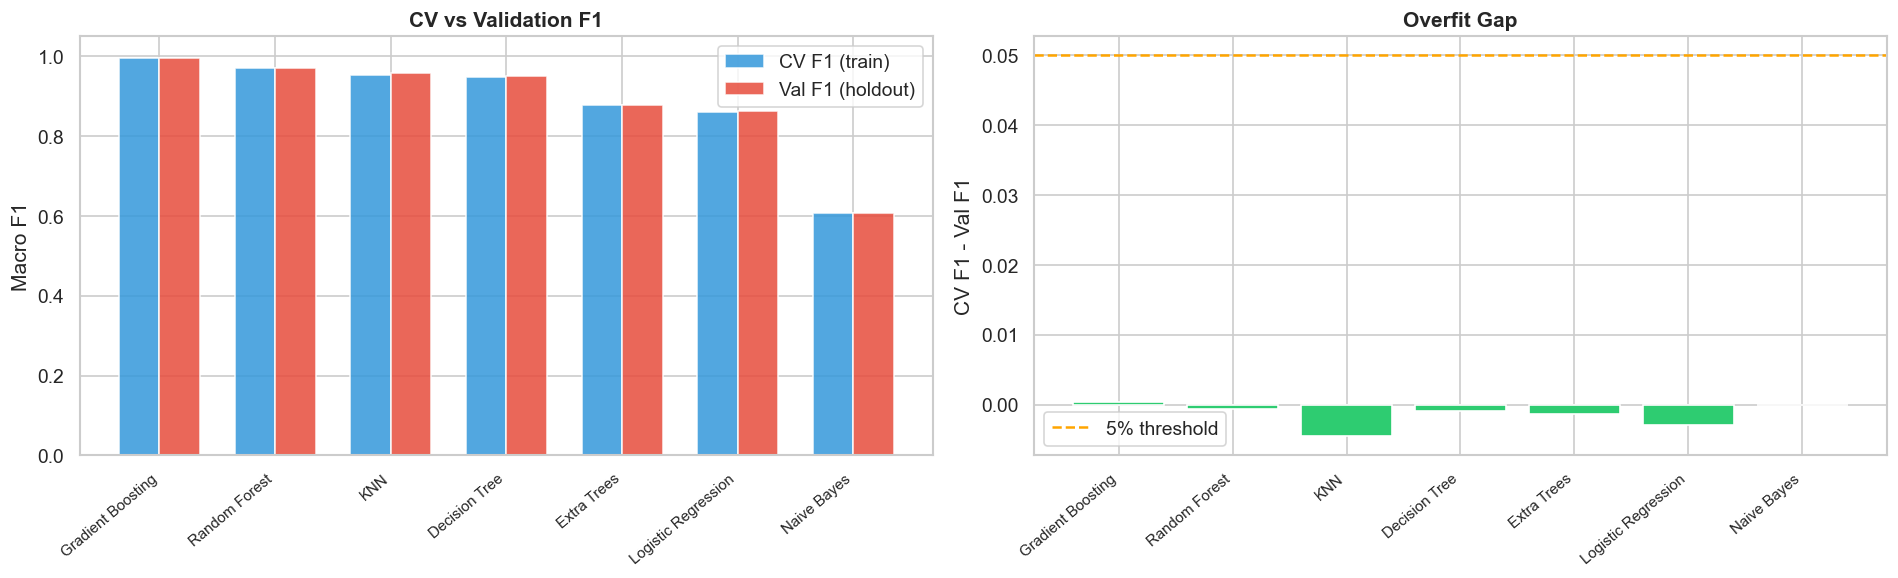

                      CV F1  Val F1  Val Acc  Overfit Gap
Gradient Boosting    0.9951  0.9948   0.9952       0.0003
Random Forest        0.9698  0.9704   0.9724      -0.0006
KNN                  0.9532  0.9577   0.9612      -0.0045
Decision Tree        0.9486  0.9496   0.9525      -0.0010
Extra Trees          0.8779  0.8792   0.8874      -0.0013
Logistic Regression  0.8596  0.8625   0.8703      -0.0029
Naive Bayes          0.6082  0.6083   0.6645      -0.0001


In [15]:
res_df = pd.DataFrame({
    n: {'CV F1':v['cv_f1_mean'],'Val F1':v['val_f1'],
        'Val Acc':v['val_acc'],'Overfit Gap':v['overfit_gap']}
    for n,v in results.items()
}).T.sort_values('Val F1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
names = res_df.index.tolist()
x = np.arange(len(names)); w = 0.35
axes[0].bar(x-w/2, res_df['CV F1'],  w, label='CV F1 (train)',    color='#3498db', alpha=0.85)
axes[0].bar(x+w/2, res_df['Val F1'], w, label='Val F1 (holdout)', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel('Macro F1'); axes[0].set_title('CV vs Validation F1', fontweight='bold')
axes[0].legend(); axes[0].set_ylim(0, 1.05)
gap_colors = ['#e74c3c' if g > 0.05 else '#2ecc71' for g in res_df['Overfit Gap']]
axes[1].bar(names, res_df['Overfit Gap'], color=gap_colors, edgecolor='white')
axes[1].axhline(0.05, color='orange', linestyle='--', label='5% threshold')
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel('CV F1 - Val F1'); axes[1].set_title('Overfit Gap', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()
print(res_df.round(4).to_string())


## 11. Best Model Selection & Test Evaluation

In [16]:
eligible   = {n: v for n,v in results.items() if v['overfit_gap'] < 0.05}
if not eligible:
    print('All models overfit slightly - selecting minimum gap model')
    eligible = results

best_name  = max(eligible, key=lambda n: eligible[n]['val_f1'])
best_model = results[best_name]['model']

print(f'Best Model : {best_name}')
print(f'Val F1     : {results[best_name]["val_f1"]:.4f}')
print(f'CV  F1     : {results[best_name]["cv_f1_mean"]:.4f} +- {results[best_name]["cv_f1_std"]:.4f}')
print(f'Overfit Gap: {results[best_name]["overfit_gap"]:.4f}')

X_tv_full = np.vstack([X_train, X_val])
y_tv_full = np.concatenate([y_train, y_val])
best_model.fit(X_tv_full, y_tv_full)
y_pred = best_model.predict(X_test)

print()
print('=' * 60)
print(f'  FINAL TEST SET PERFORMANCE - {best_name}')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=le.classes_))


Best Model : Gradient Boosting
Val F1     : 0.9948
CV  F1     : 0.9951 +- 0.0003
Overfit Gap: 0.0003

  FINAL TEST SET PERFORMANCE - Gradient Boosting
              precision    recall  f1-score   support

        High       1.00      0.99      1.00     12994
         Low       1.00      1.00      1.00     16415
    Moderate       0.99      0.99      0.99     10584

    accuracy                           1.00     39993
   macro avg       1.00      1.00      1.00     39993
weighted avg       1.00      1.00      1.00     39993



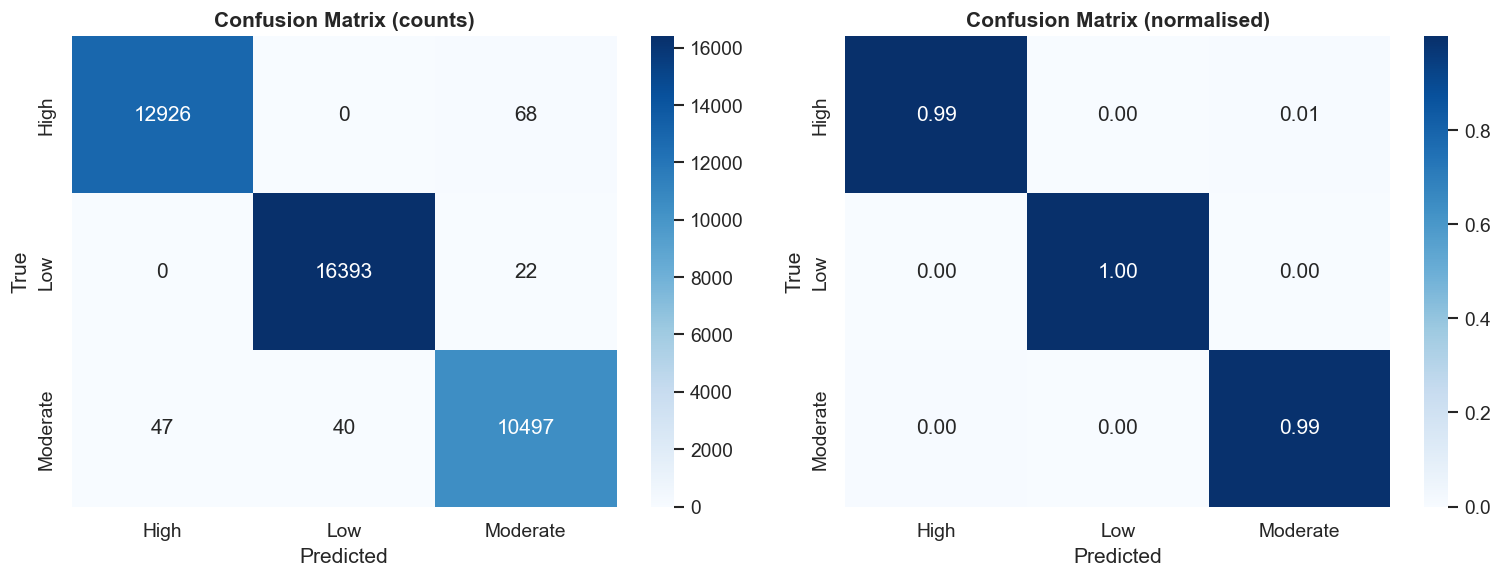

In [17]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, fmt, title in zip(axes,
    [cm, cm_norm], ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()


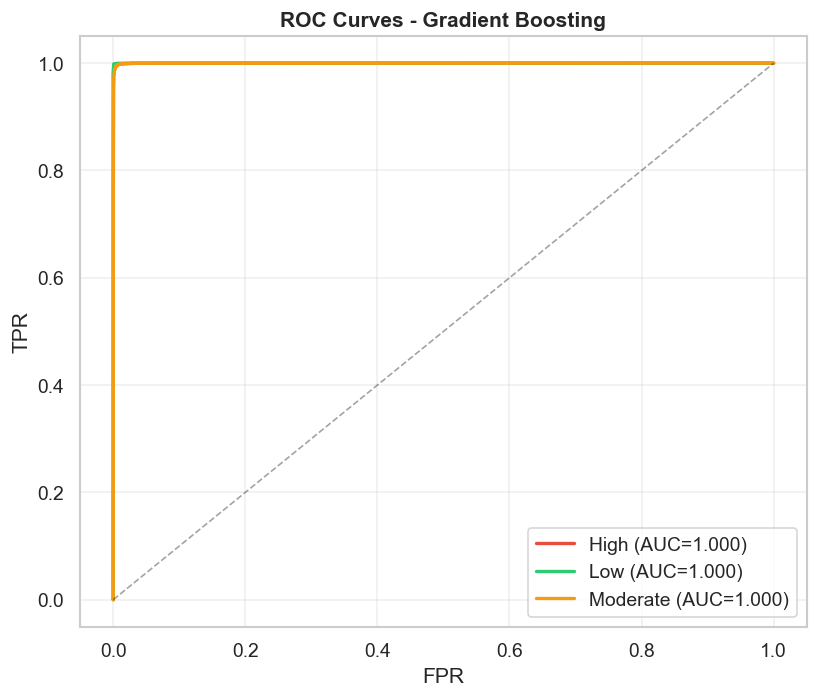

In [18]:
if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test)
    y_bin   = label_binarize(y_test, classes=[0,1,2])
    fig, ax = plt.subplots(figsize=(7, 6))
    cls_colors = {'Low':'#2ecc71','Moderate':'#f39c12','High':'#e74c3c'}
    for i, cls in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_score[:,i])
        ax.plot(fpr, tpr, lw=2, color=cls_colors[cls],
                label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curves - {best_name}', fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


## 12. Feature Importance

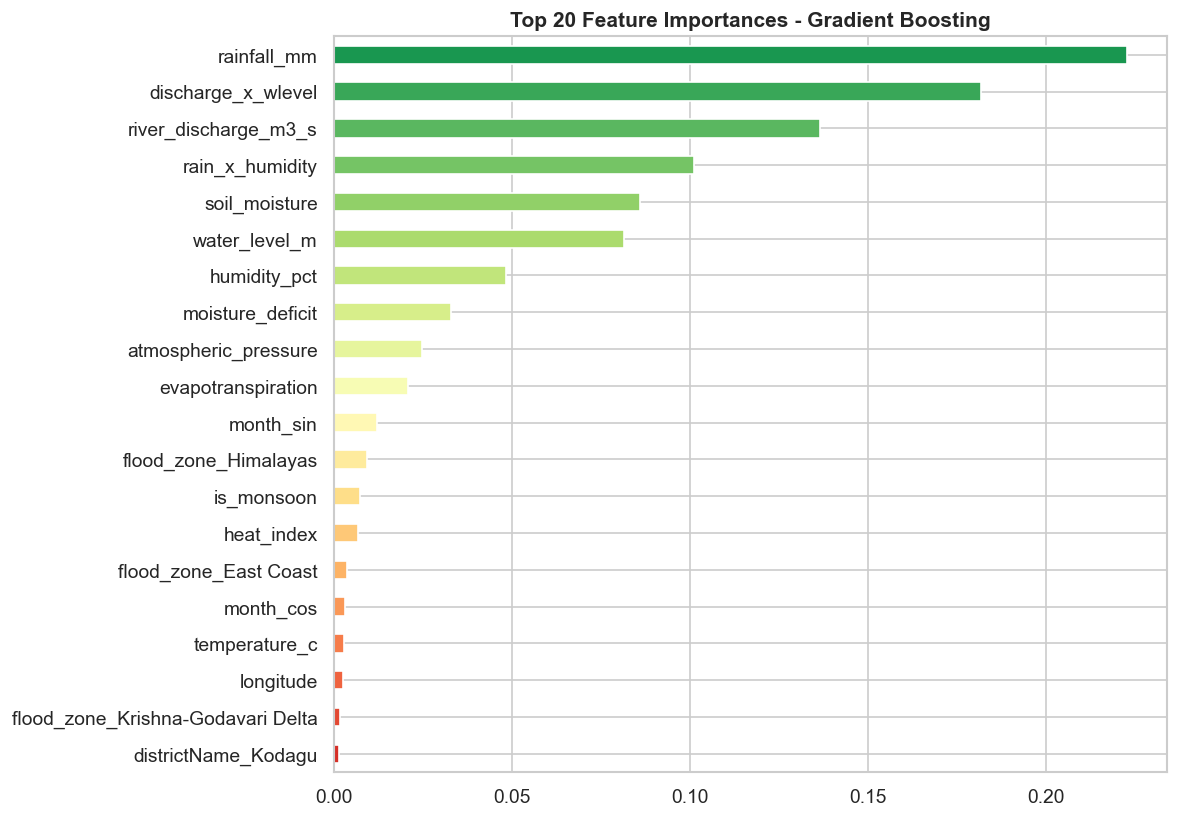

Top 10: rainfall_mm             0.2228
discharge_x_wlevel      0.1817
river_discharge_m3_s    0.1366
rain_x_humidity         0.1013
soil_moisture           0.0860
water_level_m           0.0815
humidity_pct            0.0485
moisture_deficit        0.0328
atmospheric_pressure    0.0249
evapotranspiration      0.0208


In [19]:
if hasattr(best_model, 'feature_importances_'):
    fi  = pd.Series(best_model.feature_importances_, index=feat_names).sort_values(ascending=False)
    top = fi.head(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    top[::-1].plot(kind='barh', ax=ax,
                   color=plt.cm.RdYlGn_r(np.linspace(0.1,0.9,len(top)))[::-1],
                   edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances - {best_name}', fontweight='bold')
    plt.tight_layout(); plt.show()
    print('Top 10:', top.head(10).round(4).to_string())
else:
    perm = permutation_importance(best_model, X_test[:3000], y_test[:3000],
                                  n_repeats=5, random_state=SEED, n_jobs=-1)
    fi  = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
    top = fi.head(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    top[::-1].plot(kind='barh', color='steelblue', ax=ax, edgecolor='white')
    ax.set_title(f'Top 20 Permutation Importances - {best_name}', fontweight='bold')
    plt.tight_layout(); plt.show()


## 13. Stacking Ensemble

In [20]:
top3  = sorted(results, key=lambda n: results[n]['val_f1'], reverse=True)[:3]
print(f'Base learners: {top3}')

stack = StackingClassifier(
    estimators=[(n, results[n]['model']) for n in top3],
    final_estimator=LogisticRegression(C=0.5, max_iter=300,
                                       class_weight='balanced', random_state=SEED),
    cv=5, n_jobs=-1
)
t0 = time.time()
stack.fit(X_train, y_train)
stack_val_f1 = f1_score(y_val, stack.predict(X_val), average='macro')
print(f'Stacking Val F1 : {stack_val_f1:.4f}  (best single: {results[best_name]["val_f1"]:.4f}) | {time.time()-t0:.1f}s')

final_model = stack if stack_val_f1 > results[best_name]['val_f1'] else best_model
final_name  = 'Stacking Ensemble' if stack_val_f1 > results[best_name]['val_f1'] else best_name
print(f'\nFinal model: {final_name}')

final_model.fit(X_tv_full, y_tv_full)
y_final = final_model.predict(X_test)
print()
print(classification_report(y_test, y_final, target_names=le.classes_))


Base learners: ['Gradient Boosting', 'Random Forest', 'KNN']
Stacking Val F1 : 0.9961  (best single: 0.9948) | 1113.5s

Final model: Stacking Ensemble

              precision    recall  f1-score   support

        High       1.00      1.00      1.00     12994
         Low       1.00      1.00      1.00     16415
    Moderate       0.99      0.99      0.99     10584

    accuracy                           1.00     39993
   macro avg       1.00      1.00      1.00     39993
weighted avg       1.00      1.00      1.00     39993



## 14. Save Model + All Transformers
Everything the API needs is in one `.pkl`: model, label_encoder, feature_names, num_imputer, scaler, num_cols, cat_imputer, cat_cols, clip_bounds.

In [ ]:
os.makedirs('models', exist_ok=True)
model_path = f'models/flood_model_{final_name.replace(" ", "_").lower()}.pkl'

# Use joblib with maximum compression for smaller file size
joblib.dump({
    'model':         final_model,
    'label_encoder': le,
    'feature_names': feat_names,
    'num_imputer':   num_imp,
    'scaler':        scaler,
    'num_cols':      num_cols,
    'cat_imputer':   cat_imp,
    'cat_cols':      cat_cols,
    'clip_bounds':   clip_bounds,
    'val_f1':        results[best_name]['val_f1'],
    'test_f1':       f1_score(y_test, y_final, average='macro'),
}, model_path, compress=9)

print(f'Model saved -> {model_path}')
print(f'  Model        : {final_name}')
print(f'  Val F1       : {results[best_name]["val_f1"]:.4f}')
print(f'  Test F1      : {f1_score(y_test, y_final, average="macro"):.4f}')
print(f'  Features     : {len(feat_names)}')
print(f'  Scaler center: {scaler.center_[:4].round(3)} ...')
print(f'  Clip bounds  : {list(clip_bounds.keys())}')
print()

# Sanity check - all 3 classes must predict correctly
print('Sanity check - model must correctly predict all 3 classes:')
all_ok = True
for cls in le.classes_:
    idx   = np.where(y_test == le.transform([cls])[0])[0][:5]
    preds = le.inverse_transform(final_model.predict(X_test[idx]))
    ok    = all(p == cls for p in preds)
    status = 'PASS' if ok else 'FAIL'
    print(f'  True {cls:8s} -> Predicted: {list(preds)}  [{status}]')
    if not ok: all_ok = False

if all_ok:
    print('\nAll classes OK - model is ready for deployment')
else:
    print('\nSanity check FAILED - do NOT deploy, retrain required')

Model saved -> models/flood_model_stacking_ensemble.pkl
  Model        : Stacking Ensemble
  Val F1       : 0.9948
  Test F1      : 0.9963
  Features     : 135
  Scaler center: [22.34  78.48   0.    25.223] ...
  Clip bounds  : ['rainfall_mm', 'temperature_c', 'humidity_pct', 'river_discharge_m3_s', 'water_level_m', 'soil_moisture', 'atmospheric_pressure', 'evapotranspiration']

Sanity check - model must correctly predict all 3 classes:
  True High     -> Predicted: ['High', 'High', 'High', 'High', 'High']  [PASS]
  True Low      -> Predicted: ['Low', 'Low', 'Low', 'Low', 'Low']  [PASS]
  True Moderate -> Predicted: ['Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate']  [PASS]

All classes OK - model is ready for deployment


## 15. predictor.py for API
Copy this into `app/services/predictor.py` after retraining.

In [22]:
predictor_code = '''
import logging, pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd
from app.models.schemas import CollectedFeatures
from app.config import settings

logger = logging.getLogger(__name__)

@dataclass
class PredictionResult:
    risk_level:          str
    confidence:          float
    risk_score:          float
    class_probabilities: dict

class FloodPredictor:
    def __init__(self):
        self._model=self._le=self._num_imp=self._scaler=None
        self._num_cols=self._cat_imp=self._cat_cols=self._feat_names=self._clip_bounds=None
        self.is_loaded=False; self.model_name='not loaded'

    def load_model(self, path=None):
        model_path = Path(path or settings.MODEL_PATH)
        if not model_path.exists(): raise FileNotFoundError(f'Model not found at {model_path}')
        with open(model_path, 'rb') as f: saved = pickle.load(f)
        self._model=saved['model']; self._le=saved['label_encoder']
        self._feat_names=saved['feature_names']; self._num_imp=saved['num_imputer']
        self._scaler=saved['scaler']; self._num_cols=saved['num_cols']
        self._cat_imp=saved['cat_imputer']; self._cat_cols=saved['cat_cols']
        self._clip_bounds=saved['clip_bounds']
        self.model_name=type(self._model).__name__; self.is_loaded=True
        logger.info(f'Model: {self.model_name} | features: {len(self._feat_names)} | classes: {list(self._le.classes_)}')

    def predict(self, lat, lon, date, state, district, flood_zone, features):
        if not self.is_loaded: raise RuntimeError('Model not loaded.')
        X=self._build_feature_vector(lat,lon,date,state,district,flood_zone,features)
        proba=self._model.predict_proba(X)[0]; pred_idx=int(np.argmax(proba))
        classes=list(self._le.classes_)
        class_probs={cls:round(float(p),4) for cls,p in zip(classes,proba)}
        risk_level=self._le.inverse_transform([pred_idx])[0]
        confidence=round(float(proba[pred_idx]),4)
        weights={'Low':0.0,'Moderate':0.5,'High':1.0}
        risk_score=round(sum(weights.get(c,0.5)*p for c,p in class_probs.items()),4)
        logger.info(f'Prediction: {risk_level} ({confidence:.1%}) | {class_probs}')
        return PredictionResult(risk_level=risk_level,confidence=confidence,
                                risk_score=risk_score,class_probabilities=class_probs)

    def _build_feature_vector(self,lat,lon,date,state,district,flood_zone,features):
        month=int(date[5:7])
        raw={'rainfall_mm':float(features.rainfall_mm or 0.0),
             'temperature_c':float(features.temperature_c or 25.0),
             'humidity_pct':float(features.humidity_pct or 65.0),
             'river_discharge_m3_s':float(features.river_discharge_m3_s or 50.0),
             'water_level_m':float(features.water_level_m or 100.0),
             'soil_moisture':float(features.soil_moisture or 15.0),
             'atmospheric_pressure':float(features.atmospheric_pressure or 1010.0),
             'evapotranspiration':float(features.evapotranspiration or 2.0)}
        for col,(lo,hi) in self._clip_bounds.items(): raw[col]=float(np.clip(raw[col],lo,hi))
        raw['rainfall_mm']=np.log1p(max(raw['rainfall_mm'],0))
        raw['river_discharge_m3_s']=np.log1p(max(raw['river_discharge_m3_s'],0))
        raw['water_level_m']=np.log1p(max(raw['water_level_m'],0))
        hum=np.clip(raw['humidity_pct'],0,100)
        raw['rain_x_humidity']=raw['rainfall_mm']*hum/100.0
        raw['discharge_x_wlevel']=raw['river_discharge_m3_s']*raw['water_level_m']
        raw['moisture_deficit']=max(raw['evapotranspiration'],0)-max(raw['soil_moisture'],0)
        raw['heat_index']=raw['temperature_c']*hum/100.0
        raw['month_sin']=float(np.sin(2*np.pi*month/12))
        raw['month_cos']=float(np.cos(2*np.pi*month/12))
        raw['is_monsoon']=float(month in [6,7,8,9])
        raw['dist_from_center']=float(np.sqrt((lat-20.5)**2+(lon-78.9)**2))
        raw['latitude']=lat; raw['longitude']=lon
        num_values=np.array([[raw.get(col,0.0) for col in self._num_cols]])
        num_scaled=self._scaler.transform(self._num_imp.transform(num_values))
        num_df=pd.DataFrame(num_scaled,columns=self._num_cols)
        cat_input=pd.DataFrame([{'stateName':state.strip().title(),
            'districtName':district.strip().title(),'flood_zone':flood_zone.strip()}])[self._cat_cols]
        cat_imputed=pd.DataFrame(self._cat_imp.transform(cat_input),columns=self._cat_cols)
        cat_ohe=pd.get_dummies(cat_imputed,drop_first=True)
        row_df=pd.concat([num_df,cat_ohe],axis=1)
        row_df=row_df.reindex(columns=self._feat_names,fill_value=0.0)
        return row_df.values.astype(np.float32)
'''

# Save predictor.py to disk for easy copy
with open('predictor_v3.py', 'w') as f:
    f.write(predictor_code.strip())
print('predictor_v3.py saved - copy to app/services/predictor.py')


predictor_v3.py saved - copy to app/services/predictor.py


In [23]:
# Check what water_level percentiles actually are in training data
print("water_level_m percentiles:")
print(df_filled['water_level_m'].quantile([0.33, 0.66, 0.90]).round(2))

print("\nriver_discharge percentiles:")  
print(df_filled['river_discharge_m3_s'].quantile([0.33, 0.66, 0.90]).round(2))

water_level_m percentiles:
0.33    174.07
0.66    280.15
0.90    859.05
Name: water_level_m, dtype: float64

river_discharge percentiles:
0.33      5.11
0.66     46.75
0.90    209.24
Name: river_discharge_m3_s, dtype: float64
